In [1]:
# ═══════════════════════════════════════════════════════
# CELDA 1: Instalación e Imports
# ═══════════════════════════════════════════════════════
!pip install numpy scikit-learn tensorflow matplotlib seaborn -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              top_k_accuracy_score)
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ═══════════════════════════════════════════════════════
# CELDA 2: Carga del Dataset (tus archivos .npy de Drive)
# ═══════════════════════════════════════════════════════
import gdown

# Descarga X.npy
if not os.path.exists("/content/X.npy"):
    gdown.download(
        "https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv",
        "/content/X.npy", quiet=False
    )

# Descarga Y.npy
if not os.path.exists("/content/Y.npy"):
    gdown.download(
        "https://drive.google.com/uc?id=1bGphucb5oTgLkYT2e9UB4ToaapvhKhhw",
        "/content/Y.npy", quiet=False
    )

X = np.load("/content/X.npy", mmap_mode='r')
Y_raw = np.load("/content/Y.npy", allow_pickle=True)

print("Shape X:", X.shape)
print("Shape Y_raw:", Y_raw.shape, "| Dtype:", Y_raw.dtype)

Downloading...
From (original): https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv
From (redirected): https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv&confirm=t&uuid=746dd361-e489-4f00-b5a9-d8b8eb944ec7
To: /content/X.npy
100%|██████████| 4.48G/4.48G [01:03<00:00, 71.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bGphucb5oTgLkYT2e9UB4ToaapvhKhhw
To: /content/Y.npy
100%|██████████| 1.55M/1.55M [00:00<00:00, 127MB/s]

Shape X: (22801, 128, 128, 3)
Shape Y_raw: (22801, 1) | Dtype: <U17


In [3]:
# ═══════════════════════════════════════════════════════
# CELDA 3: Preprocesamiento — Encoding + Split Estratificado
# ═══════════════════════════════════════════════════════
num_samples  = X.shape[0]
img_height   = X.shape[1]
img_width    = X.shape[2]
num_channels = X.shape[3] if X.ndim == 4 else 1

# Encode labels
y_str    = Y_raw.reshape(-1)
le       = LabelEncoder()
y_int    = le.fit_transform(y_str)
Y        = to_categorical(y_int)
num_classes = Y.shape[1]
class_names = list(le.classes_)

print(f"Imágenes: {num_samples} | Shape: {img_height}x{img_width}x{num_channels}")
print(f"Clases ({num_classes}): {class_names}")

# Split 70/15/15 con estratificación
idx = np.arange(num_samples)
idx_trainval, idx_test, Y_trainval, Y_test, y_tv_cls, y_test_cls = train_test_split(
    idx, Y, y_int, test_size=0.15, random_state=42, stratify=y_int
)
idx_train, idx_val, Y_train, Y_val, y_train_cls, y_val_cls = train_test_split(
    idx_trainval, Y_trainval, y_tv_cls, test_size=0.176, random_state=42, stratify=y_tv_cls
)

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

Imágenes: 22801 | Shape: 128x128x3
Clases (27): [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('NULL'), np.str_('a'), np.str_('b'), np.str_('bye'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('good'), np.str_('good morning'), np.str_('hello'), np.str_('little bit'), np.str_('no'), np.str_('pardon'), np.str_('please'), np.str_('project'), np.str_('whats up'), np.str_('yes')]
Train: 15969 | Val: 3411 | Test: 3421


In [4]:
# ═══════════════════════════════════════════════════════
# CELDA 4: Generador por batches para CNN (mantiene shape 4D)
# ═══════════════════════════════════════════════════════
class BatchGenerator(keras.utils.Sequence):
    def __init__(self, X_mmap, indices, labels, batch_size=32, augment=False):
        self.X       = X_mmap
        self.idx     = indices
        self.labels  = labels
        self.bs      = batch_size
        self.augment = augment

    def __len__(self):
        return int(np.ceil(len(self.idx) / self.bs))

    def __getitem__(self, i):
        batch_idx = self.idx[i*self.bs:(i+1)*self.bs]
        imgs = np.array(self.X[batch_idx], dtype=np.float32) / 255.0
        if imgs.ndim == 3:                          # agrega canal si falta
            imgs = imgs[..., np.newaxis]
        if self.augment:
            imgs = self._augment(imgs)
        return imgs, self.labels[i*self.bs:(i+1)*self.bs]

    def _augment(self, imgs):
        # Flip horizontal aleatorio
        mask = np.random.rand(len(imgs)) > 0.5
        imgs[mask] = imgs[mask, :, ::-1, :]
        # Brillo aleatorio ±20%
        brightness = np.random.uniform(0.8, 1.2, (len(imgs), 1, 1, 1))
        imgs = np.clip(imgs * brightness, 0, 1)
        return imgs

BATCH_SIZE = 32
train_gen = BatchGenerator(X, idx_train, Y_train, BATCH_SIZE, augment=True)
val_gen   = BatchGenerator(X, idx_val,   Y_val,   BATCH_SIZE, augment=False)
test_gen  = BatchGenerator(X, idx_test,  Y_test,  BATCH_SIZE, augment=False)

print(f"Batches train: {len(train_gen)} | val: {len(val_gen)} | test: {len(test_gen)}")

Batches train: 500 | val: 107 | test: 107


In [5]:
# ═══════════════════════════════════════════════════════
# CELDA 5: Selección de métricas
# ═══════════════════════════════════════════════════════
# ─── JUSTIFICACIÓN ───────────────────────────────────
# Problema: Clasificación multiclase de señas de mano
#
# MÉTRICA DE OPTIMIZACIÓN (la que el modelo minimiza/maximiza internamente):
#   → Loss: categorical_crossentropy
#     Razón: mide distancia entre distribución predicha y one-hot real.
#     Sensible a la confianza del modelo, no solo si acierta o no.
#
# MÉTRICA DE SATISFACCIÓN (la que evalúa si el modelo es "suficientemente bueno"):
#   → Primary:   Accuracy (Top-1)   — ¿Acierta la clase exacta?
#   → Secondary: Top-3 Accuracy     — ¿Está la clase real entre las 3 primeras?
#   → Additional: Macro F1-Score    — Penaliza clases con poco soporte (clases raras)
#
# CRITERIO DE ÉXITO:
#   Test Accuracy >= 0.85  →  modelo aceptable para producción
#   Test Accuracy >= 0.90  →  modelo robusto
# ──────────────────────────────────────────────────────

OPTIMIZER_METRIC    = "categorical_crossentropy"
SATISFACTION_METRIC = "accuracy"
THRESHOLD_ACCEPTABLE = 0.85
THRESHOLD_ROBUST     = 0.90

print("Métrica de optimización :", OPTIMIZER_METRIC)
print("Métrica de satisfacción :", SATISFACTION_METRIC)
print(f"Umbral de aceptación    : {THRESHOLD_ACCEPTABLE}")
print(f"Umbral robusto          : {THRESHOLD_ROBUST}")

Métrica de optimización : categorical_crossentropy
Métrica de satisfacción : accuracy
Umbral de aceptación    : 0.85
Umbral robusto          : 0.9


In [6]:
# ═══════════════════════════════════════════════════════
# CELDA 6: Arquitectura CNN
# ═══════════════════════════════════════════════════════
def build_cnn(img_h, img_w, channels, num_classes):
    inputs = keras.Input(shape=(img_h, img_w, channels), name="input_img")

    # ── Bloque 1: extracción de bordes y texturas básicas ──
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu', name='conv1_1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu', name='conv1_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Bloque 2: patrones intermedios ──
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Bloque 3: patrones complejos ──
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    # ── Clasificador ──
    x = layers.GlobalAveragePooling2D()(x)   # mejor que Flatten para generalización
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name="HandSign_CNN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=OPTIMIZER_METRIC,
        metrics=[SATISFACTION_METRIC, keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
    )
    return model

model = build_cnn(img_height, img_width, num_channels, num_classes)
model.summary()

Model: "HandSign_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 328,763 (1.25 MB)

 Trainable params: 327,867 (1.25 MB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
# ═══════════════════════════════════════════════════════
# CELDA 7: Entrenamiento
# ═══════════════════════════════════════════════════════
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "/content/best_cnn_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("\nEntrenamiento finalizado.")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0606 - loss: 3.3152 - top3_acc: 0.1539
Epoch 1: val_accuracy improved from None to 0.01524, saving model to /content/best_cnn_model.keras

Epoch 1: finished saving model to /content/best_cnn_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 76ms/step - accuracy: 0.0854 - loss: 3.1567 - top3_acc: 0.2113 - val_accuracy: 0.0152 - val_loss: 4.5114 - val_top3_acc: 0.0938 - learning_rate: 0.0010
Epoch 2/60
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2109 - loss: 2.5124 - top3_acc: 0.4433
Epoch 2: val_accuracy improved from 0.01524 to 0.09968, saving model to /content/best_cnn_model.keras

Epoch 2: finished saving model to /content/best_cnn_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.2699 - loss: 2.2897 - top3_acc: 0.5225 - val_accuracy: 0.0997 - val_loss: 3.6786 - val_top3_acc: 0.2782 - learning_rate: 0.0010
Epoch 3/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4773 - loss: 1.5933 

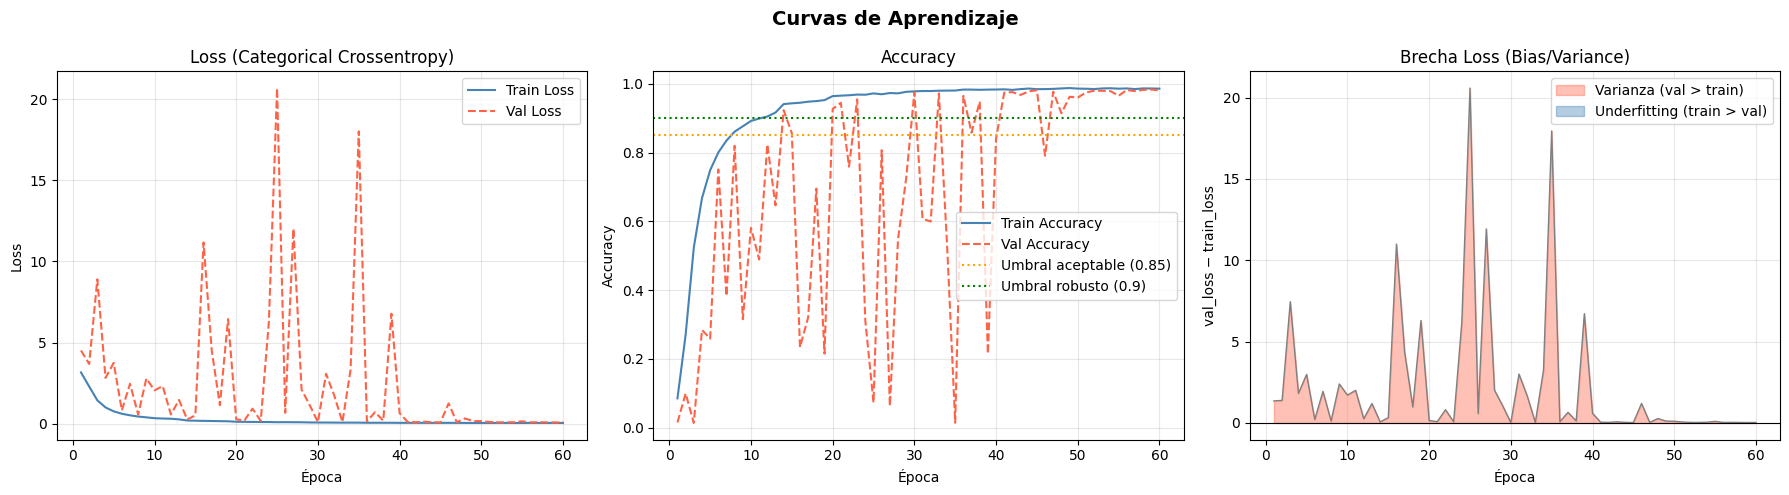


DIAGNÓSTICO BIAS / VARIANCE
Train Loss final : 0.0450
Val   Loss final : 0.0779
Brecha (gap)     : 0.0329
Mejor Val Acc    : 0.9833

✅ BALANCE OK: Bias y Variance en rango aceptable.


In [8]:
# ═══════════════════════════════════════════════════════
# CELDA 8: Curvas de aprendizaje + Análisis Bias/Variance
# ═══════════════════════════════════════════════════════
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Curvas de Aprendizaje", fontsize=14, fontweight='bold')

# ── Loss ──
axes[0].plot(epochs_ran, hist['loss'],     label='Train Loss',  color='steelblue')
axes[0].plot(epochs_ran, hist['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
axes[0].set_title('Loss (Categorical Crossentropy)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──
axes[1].plot(epochs_ran, hist['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(epochs_ran, hist['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
axes[1].axhline(THRESHOLD_ACCEPTABLE, color='orange', linestyle=':', label=f'Umbral aceptable ({THRESHOLD_ACCEPTABLE})')
axes[1].axhline(THRESHOLD_ROBUST,     color='green',  linestyle=':', label=f'Umbral robusto ({THRESHOLD_ROBUST})')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Brecha Bias/Variance ──
gap = np.array(hist['val_loss']) - np.array(hist['loss'])
axes[2].fill_between(epochs_ran, gap, 0, where=(gap > 0), alpha=0.4, color='tomato',   label='Varianza (val > train)')
axes[2].fill_between(epochs_ran, gap, 0, where=(gap < 0), alpha=0.4, color='steelblue', label='Underfitting (train > val)')
axes[2].plot(epochs_ran, gap, color='gray', linewidth=1)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Brecha Loss (Bias/Variance)')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('val_loss − train_loss')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Diagnóstico automático ──
final_train_loss = hist['loss'][-1]
final_val_loss   = hist['val_loss'][-1]
final_gap        = final_val_loss - final_train_loss
best_val_acc     = max(hist['val_accuracy'])

print("\n" + "="*50)
print("DIAGNÓSTICO BIAS / VARIANCE")
print("="*50)
print(f"Train Loss final : {final_train_loss:.4f}")
print(f"Val   Loss final : {final_val_loss:.4f}")
print(f"Brecha (gap)     : {final_gap:.4f}")
print(f"Mejor Val Acc    : {best_val_acc:.4f}")

if final_train_loss > 0.4:
    print("\n⚠️  HIGH BIAS (Underfitting): El modelo no está aprendiendo bien.")
    print("   → Aumenta capas, épocas o reduce Dropout.")
elif final_gap > 0.3:
    print("\n⚠️  HIGH VARIANCE (Overfitting): Memoriza el train set.")
    print("   → Aumenta Dropout, usa más augmentation o reduce la red.")
else:
    print("\n✅ BALANCE OK: Bias y Variance en rango aceptable.")

In [11]:
# ═══════════════════════════════════════════════════════
# CELDA 9: Evaluación en Test + Análisis de Errores (Corregida)
# ═══════════════════════════════════════════════════════
from sklearn.metrics import accuracy_score, classification_report

# ── Métricas globales de Keras (usando return_dict=True para evitar errores) ──
test_results_dict = model.evaluate(test_gen, verbose=0, return_dict=True)
print("="*50)
print("EVALUACIÓN EN TEST SET")
print("="*50)
for name, val in test_results_dict.items():
    print(f"  {name:20s}: {val:.4f}")

# ── Predicciones ──
Y_pred_proba = model.predict(test_gen, verbose=0)
Y_pred_cls   = np.argmax(Y_pred_proba, axis=1)

# Extraer etiquetas reales del generador de forma segura
Y_true_cls = []
for i in range(len(test_gen)):
    _, batch_y = test_gen[i]
    Y_true_cls.extend(np.argmax(batch_y, axis=1))

Y_true_cls = np.array(Y_true_cls)[:len(Y_pred_cls)]

# ── Satisfacción: cumple el umbral? ──
# Calculamos el accuracy con sklearn para ignorar los nombres internos de Keras
test_acc = accuracy_score(Y_true_cls, Y_pred_cls)

print(f"\nMétrica de satisfacción (Accuracy): {test_acc:.4f}")
if test_acc >= THRESHOLD_ROBUST:
    print(f"✅ MODELO ROBUSTO — supera umbral robusto ({THRESHOLD_ROBUST})")
elif test_acc >= THRESHOLD_ACCEPTABLE:
    print(f"🟡 MODELO ACEPTABLE — supera umbral aceptable ({THRESHOLD_ACCEPTABLE})")
else:
    print(f"❌ MODELO INSUFICIENTE — no supera umbral aceptable ({THRESHOLD_ACCEPTABLE})")

# ── Classification Report ──
print("\nReporte de clasificación:")
print(classification_report(Y_true_cls, Y_pred_cls, target_names=class_names))

EVALUACIÓN EN TEST SET
  accuracy            : 0.9845
  loss                : 0.0599
  top3_acc            : 0.9991

Métrica de satisfacción (Accuracy): 0.9845
✅ MODELO ROBUSTO — supera umbral robusto (0.9)

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       130
           1       0.98      0.98      0.98       129
           2       0.98      1.00      0.99       130
           3       1.00      1.00      1.00       130
           4       0.98      0.95      0.96       129
           5       0.98      1.00      0.99       130
           6       0.97      0.99      0.98       130
           7       0.98      0.97      0.97       130
           8       0.96      0.96      0.96       130
           9       0.98      0.99      0.98       130
        NULL       1.00      0.81      0.89        47
           a       0.98      0.98      0.98       129
           b       0.99      0.99      0.99       130
         

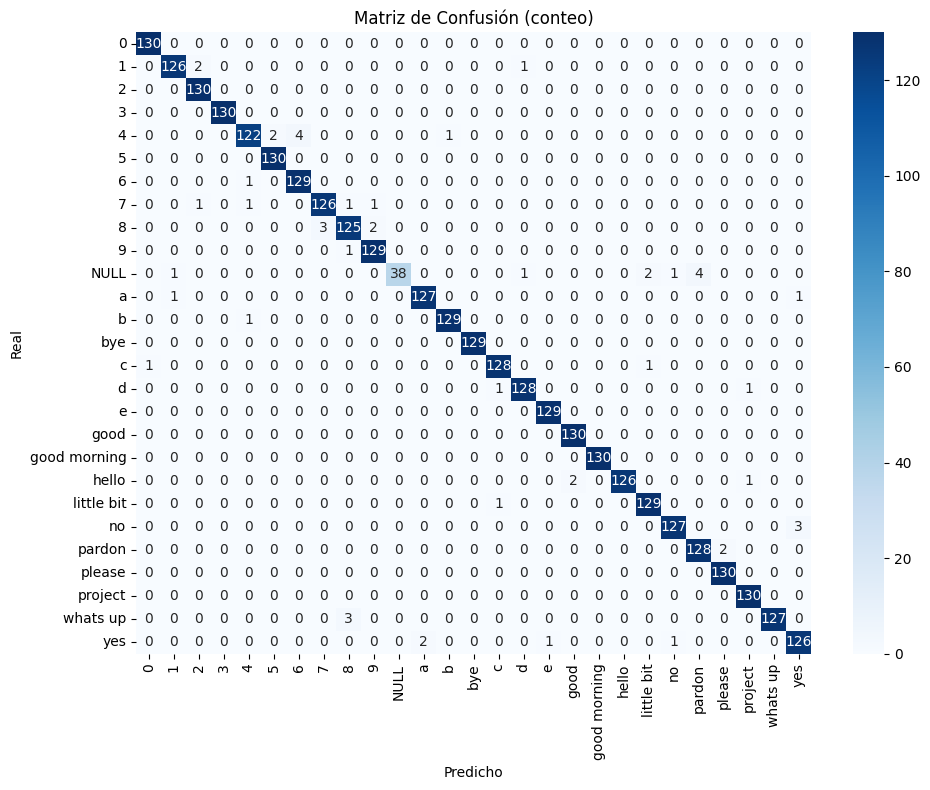

In [20]:
# ═══════════════════════════════════════════════════════
# CELDA 10: Matriz de Confusión
# ═══════════════════════════════════════════════════════
cm = confusion_matrix(Y_true_cls, Y_pred_cls)

fig, ax = plt.subplots(figsize=(10, 8))

# Solo Conteo absoluto
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Matriz de Confusión (conteo)')
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Total errores: 53 / 3421 (1.5%)
Confianza media en errores  : 0.765
Confianza mediana en errores: 0.812

Errores con confianza > 0.80: 27 (modelo equivocado pero muy seguro)


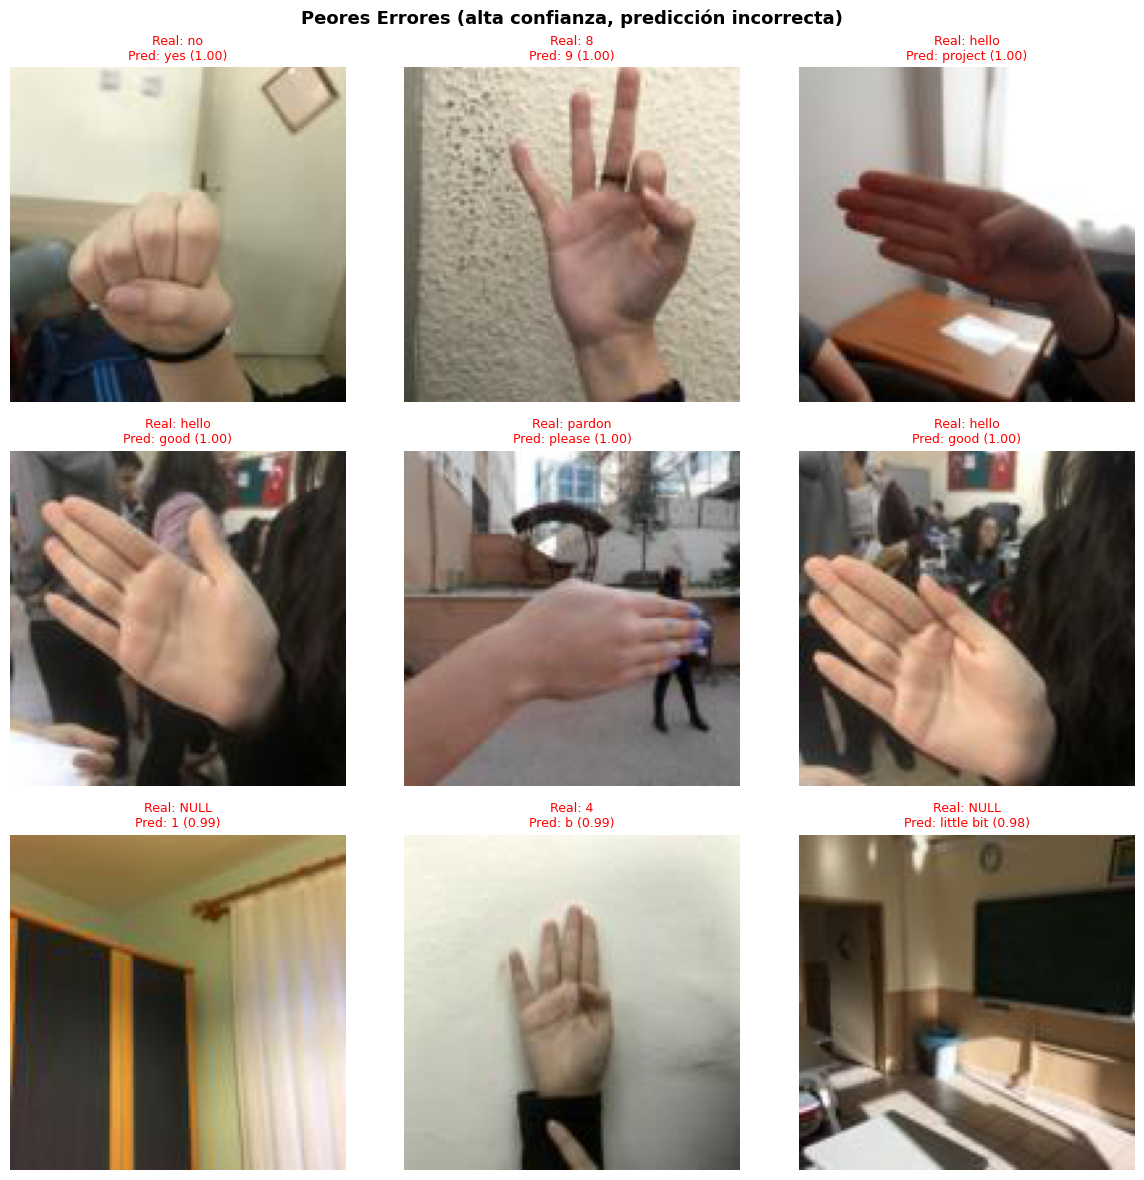


Clases con mayor tasa de error:
Clase             Error Rate   N muestras
----------------------------------------
NULL                  0.191           47
4                     0.054          129
8                     0.038          130
7                     0.031          130
yes                   0.031          130
1                     0.023          129
hello                 0.023          129
no                    0.023          130
whats up              0.023          130
a                     0.016          129
c                     0.015          130
d                     0.015          130
pardon                0.015          130
6                     0.008          130
9                     0.008          130
b                     0.008          130
little bit            0.008          130
0                     0.000          130
2                     0.000          130
3                     0.000          130
5                     0.000          130
bye                   0

In [13]:
# ═══════════════════════════════════════════════════════
# CELDA 11: Análisis de errores — Ejemplos mal clasificados
# ═══════════════════════════════════════════════════════
# Confianzas del modelo en predicciones incorrectas
errors_mask    = (Y_pred_cls != Y_true_cls)
error_indices  = np.where(errors_mask)[0]
error_confidences = Y_pred_proba[error_indices].max(axis=1)

print(f"Total errores: {len(error_indices)} / {len(Y_true_cls)} "
      f"({100*len(error_indices)/len(Y_true_cls):.1f}%)")
print(f"Confianza media en errores  : {error_confidences.mean():.3f}")
print(f"Confianza mediana en errores: {np.median(error_confidences):.3f}")

# Errores con alta confianza (los más preocupantes)
high_conf_errors = error_indices[error_confidences > 0.80]
print(f"\nErrores con confianza > 0.80: {len(high_conf_errors)} "
      f"(modelo equivocado pero muy seguro)")

# Visualizar los 9 peores errores (mayor confianza equivocada)
if len(high_conf_errors) > 0:
    sorted_errors = high_conf_errors[np.argsort(-error_confidences[error_confidences > 0.80])]
    n_show = min(9, len(sorted_errors))

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle("Peores Errores (alta confianza, predicción incorrecta)", fontsize=13, fontweight='bold')

    for i, err_pos in enumerate(sorted_errors[:n_show]):
        real_data_idx = idx_test[err_pos]
        img = np.array(X[real_data_idx], dtype=np.float32)
        if img.ndim == 3 and img.shape[-1] == 1:
            img_show = img.squeeze()
        else:
            img_show = img
        img_vis = (img_show - img_show.min()) / (img_show.max() - img_show.min() + 1e-8)

        true_label = class_names[Y_true_cls[err_pos]]
        pred_label = class_names[Y_pred_cls[err_pos]]
        conf       = Y_pred_proba[err_pos, Y_pred_cls[err_pos]]

        ax = axes[i // 3][i % 3]
        if img_vis.ndim == 2:
            ax.imshow(img_vis, cmap='gray')
        else:
            ax.imshow(img_vis)
        ax.axis('off')
        ax.set_title(f"Real: {true_label}\nPred: {pred_label} ({conf:.2f})",
                     color='red', fontsize=9)

    plt.tight_layout()
    plt.savefig('/content/error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

# Clases con mayor tasa de error
per_class_errors = []
for c in range(num_classes):
    mask_c = (Y_true_cls == c)
    if mask_c.sum() == 0:
        continue
    error_rate = (Y_pred_cls[mask_c] != c).mean()
    per_class_errors.append((class_names[c], error_rate, mask_c.sum()))

per_class_errors.sort(key=lambda x: -x[1])
print("\nClases con mayor tasa de error:")
print(f"{'Clase':<15} {'Error Rate':>12} {'N muestras':>12}")
print("-" * 40)
for cls, rate, n in per_class_errors:
    flag = " ⚠️" if rate > 0.20 else ""
    print(f"{cls:<15} {rate:>11.3f} {n:>12}{flag}")

In [15]:
# ═══════════════════════════════════════════════════════
# CELDA 12: Resumen final del experimento
# ═══════════════════════════════════════════════════════
from sklearn.metrics import f1_score, top_k_accuracy_score

macro_f1 = f1_score(Y_true_cls, Y_pred_cls, average='macro')

# Calculamos top-3 accuracy usando sklearn para evitar errores de Keras
top3_acc = top_k_accuracy_score(Y_true_cls, Y_pred_proba, k=3)

print("="*55)
print("       RESUMEN FINAL DEL EXPERIMENTO CNN")
print("="*55)
print(f"  Arquitectura     : CNN 3 bloques Conv + GAP")
print(f"  Optimizador      : Adam (lr=1e-3)")
print(f"  Loss (optimiz.)  : {OPTIMIZER_METRIC}")
print(f"  Clases           : {num_classes}")
print(f"  Train samples    : {len(idx_train)}")
print(f"  Test samples     : {len(idx_test)}")
print("-"*55)
print(f"  Test Accuracy    : {test_acc:.4f}  (umbral: {THRESHOLD_ACCEPTABLE})")
print(f"  Top-3 Accuracy   : {top3_acc:.4f}")
print(f"  Macro F1-Score   : {macro_f1:.4f}")
print(f"  Total errores    : {len(error_indices)} ({100*len(error_indices)/len(Y_true_cls):.1f}%)")
print("-"*55)

# Bias/Variance resumen
print(f"  Train Loss final : {hist['loss'][-1]:.4f}")
print(f"  Val   Loss final : {hist['val_loss'][-1]:.4f}")
gap_final = hist['val_loss'][-1] - hist['loss'][-1]
if abs(gap_final) < 0.1:
    bv_diag = " Bien balanceado"
elif gap_final > 0.1:
    bv_diag = "⚠️  Tendencia a overfitting (alta varianza)"
else:
    bv_diag = "⚠️  Tendencia a underfitting (alto bias)"
print(f"  Bias/Variance    : {bv_diag}")
print("="*55)

       RESUMEN FINAL DEL EXPERIMENTO CNN
  Arquitectura     : CNN 3 bloques Conv + GAP
  Optimizador      : Adam (lr=1e-3)
  Loss (optimiz.)  : categorical_crossentropy
  Clases           : 27
  Train samples    : 15969
  Test samples     : 3421
-------------------------------------------------------
  Test Accuracy    : 0.9845  (umbral: 0.85)
  Top-3 Accuracy   : 0.9991
  Macro F1-Score   : 0.9822
  Total errores    : 53 (1.5%)
-------------------------------------------------------
  Train Loss final : 0.0450
  Val   Loss final : 0.0779
  Bias/Variance    : ✅ Bien balanceado
